# Telecom Customer Churn Prediction and Retention Analytics System

### Import Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,OneHotEncoder

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,roc_auc_score,average_precision_score

import warnings
warnings.filterwarnings("ignore")

### Data loading and Exploring

In [4]:
df=pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print ("Unique values :  \n",df.nunique())

Unique values :  
 customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Cleaning

### Handling duplicte values

In [7]:
# NO duplicate values in data ,customerID has uique values
df.duplicated().sum()

0

In [8]:
# Dropping  customerID column
df=df.drop(columns=['customerID'])

In [9]:
# CHANGING DATA TYPE OF TotalCharges and handling null values
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors='coerce')

In [10]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### NULL VALUES in Total Charges with Tenure ZERO

In [11]:
df[df["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [12]:
# FILLING NULL VALUES IN TOTAL CHARGES WITH EXACT AMOUNT IN  MONTHLY CHARGES BECAUSE TENURE WAS ZERO
df["TotalCharges"]=df["TotalCharges"].fillna(df["MonthlyCharges"]* df["tenure"])

In [13]:
df[df["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [14]:
# CUSTOMERS WITH ZERO TENURE HAS NO NULL  values in TOTAL CAHRGES
df[df["tenure"]==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Feature Engineering

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# CUSTOMER WITH ZERO TENURE HAS ZERO TOTAL CHARGES  AND AVERAGE MONTHLY CHARGES
df["AvgMonthlySpend"] = np.where(df["tenure"] == 0,0,df["TotalCharges"] / df["tenure"])

In [18]:
# CUSTOMERS WITH TENURE LESS THAN 12 ARE NEW CUSTOMERS
df["IsNewCustomer"] = (df["tenure"] < 12).astype(int)

In [19]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsNewCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,55.573529,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000,1


In [20]:
df[df["tenure"]==0].head(11)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsNewCustomer
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No,0.0,1
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No,0.0,1
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No,0.0,1
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No,0.0,1
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No,0.0,1
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No,0.0,1
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No,0.0,1
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No,0.0,1
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No,0.0,1
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,No,Two year,No,Mailed check,73.35,0.0,No,0.0,1


In [21]:
df[df["tenure"]==1].head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsNewCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,1
20,Male,1,No,No,1,No,No phone service,DSL,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,39.65,1
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes,20.15,1
27,Male,0,Yes,Yes,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,No,Electronic check,30.20,30.20,Yes,30.20,1
33,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.20,20.20,No,20.20,1


In [22]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,IsNewCustomer
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.218275,-0.022396
tenure,0.016567,1.000000,0.247900,0.826178,0.249391,-0.736687
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.994355,-0.186611
TotalCharges,0.103006,0.826178,0.651174,1.000000,0.651435,-0.576747
AvgMonthlySpend,0.218275,0.249391,0.994355,0.651435,1.000000,-0.186720
IsNewCustomer,-0.022396,-0.736687,-0.186611,-0.576747,-0.186720,1.000000


* MonthlyCharges ↔ AvgMonthlySpend
* The Correlation between them is 0.957328

* AvgMonthlySpend is almost the same information as MonthlyCharges.
* It is not introducing much new information.

* + AvgMonthlySpend was engineered from existing billing variables. Correlation analysis showed a very strong relationship with MonthlyCharges (0.957), indicating substantial overlap in information. To reduce multicollinearity and improve model interpretability, the feature was removed after confirming that model performance did not deteriorate.

* ====================================================================

* TotalCharges ↔ AvgMonthlySpend

* Correlation between them is 0.764489

* Strong positive correlation.
* Expected because TotalCharges is influenced by monthly spending.
* + IsNewCustomer was created to capture whether a customer is in the early stage of the customer lifecycle. Although derived from tenure, it provides a business-oriented categorical representation that may help the model capture non-linear tenure effects.




In [23]:
# df.corr(method="pearson",numeric_only=True)
# df.corr(method="spearman",numeric_only=True)
# df.corr(method="kendall",numeric_only=True)

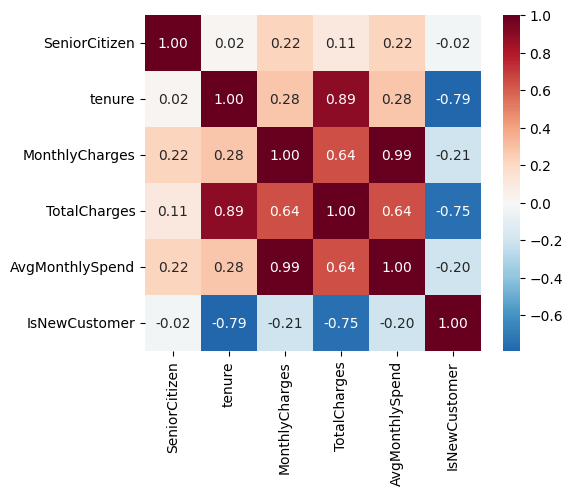

In [24]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    df.corr(method="spearman", numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True
)
plt.tight_layout()
plt.show()

In [25]:
# DROPPED THE COLUMNS AvgMonthlySpend & IsNewCustomer
df=df.drop([ 'AvgMonthlySpend', 'IsNewCustomer'], axis=1)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# defining Target Column

In [27]:
# Encodeing values of the target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])  # No→0, Yes→1

In [28]:
df.shape

(7043, 20)

In [29]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [30]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [31]:
X.shape

(7043, 19)

In [32]:
y.shape

(7043,)

In [33]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: Churn
Non-Null Count  Dtype
--------------  -----
7043 non-null   int32
dtypes: int32(1)
memory usage: 27.6 KB


In [34]:
y.value_counts(normalize=True)*100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

# Train Test Split

In [35]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)

print(X.shape,y.shape)
print("-"*40)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(7043, 19) (7043,)
----------------------------------------
(5634, 19) (5634,) (1409, 19) (1409,)


In [36]:
df.shape

(7043, 20)

In [37]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


# DATA PREPROCESSING

## Column declaration

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [39]:
# Numerical columns
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Binary categorical columns
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "SeniorCitizen"
]

# Nominal categorical columns
nominal_cols = [
    "gender",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

# Column Transformation

In [40]:
# Numerical pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Binary pipeline
binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
])

# Nominal pipeline
nominal_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("bin", binary_transformer, binary_cols),
        ("nom", nominal_transformer, nominal_cols)
    ],
    remainder='drop'
)

In [41]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Partner', 'Dependents', 'PhoneService',
                                  'PaperlessBilling', 'SeniorCitizen']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['gender', 'MultipleLines', 'InternetService',
                                  'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport',
                                  'StreamingTV', 'StreamingMovies', 'Contract',
                                  'PaymentMethod'])])

In [42]:
# to handle class imbalance in XGBoost.
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)
scale_pos_weight

2.768561872909699

# Pipeline

In [43]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
))
])

In [44]:
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Partner', 'Dep...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=1,
                               num_parallel_tree=None, ...))])

## Hyperparameter

In [45]:
param_dist={
    "model__n_estimators":[100,200,300,400,500],
    "model__max_depth":[3,4,5,6,7,8],
    "model__learning_rate":[0.01,0.05,0.1,0.2],
    "model__subsample":[0.6,0.8,1.0],
    "model__colsample_bytree":[0.6,0.8,1.0],
    "model__min_child_weight":[1,3,5],
    "model__gamma":[0,0.1,0.3,0.5]
}

# Hyperparameter Tuning

In [46]:
from sklearn.model_selection import RandomizedSearchCV

random_search=RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [47]:
# # ##To verify all valid parameter names
# for param in random_search.get_params().keys():
#     print(param)

# Training  Model

In [48]:
# 1. Train model
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges']),
                                                                              ('bin',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                                               un...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__gamma': [0, 0.1, 0.3, 0.5],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 4, 5, 6, 7, 8],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [100, 200, 300,
                                                                400, 500],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc')


# Best_Score Best_Parameters Best_Estimators

In [49]:
# finding the best score,This is the mean CV score of the best hyperparameters
print("Best Score :",random_search.best_score_ )

# fetching the best parameters
print("Best Parameters :",random_search.best_params_)

print()
# using best estimator to create best model
best_model = random_search.best_estimator_
best_model

Best Score : 0.8490402425600478
Best Parameters : {'model__subsample': 0.6, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__gamma': 0.5, 'model__colsample_bytree': 1.0}



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Partner', 'Dep...
                               feature_types=None, feature_weights=None,
                               gamma=0.5, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=5,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=400, n_jobs=1,
                               num_parallel_tree=None, ...))])

## Get probability predictions

In [50]:
# [:, 1]-selects only the probability of Class 1 (Churn):
# y_prob contains the predicted probabilities:
# y_pred contains only 0s and 1s:

y_prob = best_model.predict_proba(X_test)[:, 1]
print("y_prob--->",y_prob)

y_prob---> [0.04926965 0.8682801  0.1722724  ... 0.28379413 0.057095   0.04137447]


***Threshold Tuning***

In [51]:

for threshold in [0.3,0.4,0.45,0.5,0.55,0.6,0.7]:
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\nThreshold = {threshold}")
    print("accuracy:",accuracy_score(y_test,y_pred))
    print("Precision:", precision_score(y_test,y_pred))
    print("Recall:", recall_score(y_test,y_pred))
    print("F1:", f1_score(y_test,y_pred))


Threshold = 0.3
accuracy: 0.6628814762242725
Precision: 0.43599493029150826
Recall: 0.9197860962566845
F1: 0.5915735167669819

Threshold = 0.4
accuracy: 0.7097232079489
Precision: 0.4741506646971935
Recall: 0.8582887700534759
F1: 0.6108468125594672

Threshold = 0.45
accuracy: 0.7338537970191625
Precision: 0.4992
Recall: 0.8342245989304813
F1: 0.6246246246246246

Threshold = 0.5
accuracy: 0.7501774308019872
Precision: 0.5189003436426117
Recall: 0.8074866310160428
F1: 0.6317991631799164

Threshold = 0.55
accuracy: 0.7622427253371186
Precision: 0.5365853658536586
Recall: 0.7647058823529411
F1: 0.6306504961411246

Threshold = 0.6
accuracy: 0.7735982966643009
Precision: 0.5588865096359743
Recall: 0.6978609625668449
F1: 0.6206896551724138

Threshold = 0.7
accuracy: 0.8069552874378992
Precision: 0.6545454545454545
Recall: 0.5775401069518716
F1: 0.6136363636363636


In [52]:
# goal is to maximize Recall.
# analyzed different thresholds and found 0.45 works better.
# Lower threshold selected to improve churn recall.
# Catch as many churn customers as possible, even if some non-churn customers are incorrectly flagged.
# Missing a churn customer is costly.

threshold = 0.45
y_pred = (y_prob >= threshold).astype(int)
print("y_pred--->",y_pred)

y_pred---> [0 1 0 ... 0 0 0]


# METRICS

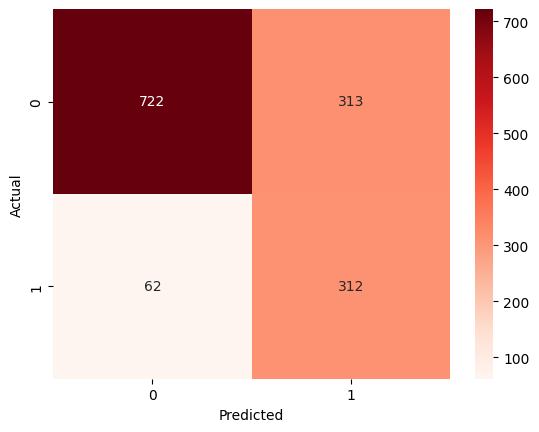

In [53]:
# sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='yellow')
sns.heatmap(confusion_matrix(y_test, y_pred),annot=True,fmt='d',cmap='Reds' )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Metrics

In [54]:
print("Confusion Matrix         \n",confusion_matrix(y_test, y_pred))
print("Accuracy----------------->",accuracy_score(y_test, y_pred))
print("Precision---------------->",precision_score(y_test, y_pred))
print("Recall------------------->",recall_score(y_test, y_pred))
print("F1 Score----------------->",f1_score(y_test, y_pred))
print("ROC-AUC------------------>",roc_auc_score(y_test, y_prob))
print("PR-AUC------------------->",average_precision_score(y_test, y_prob))
print("Classification Report  \n",classification_report(y_test, y_pred))

Confusion Matrix         
 [[722 313]
 [ 62 312]]
Accuracy-----------------> 0.7338537970191625
Precision----------------> 0.4992
Recall-------------------> 0.8342245989304813
F1 Score-----------------> 0.6246246246246246
ROC-AUC------------------> 0.8468418197318454
PR-AUC-------------------> 0.6632629455238251
Classification Report  
               precision    recall  f1-score   support

           0       0.92      0.70      0.79      1035
           1       0.50      0.83      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.73      0.75      1409



# **Threshold tuning was performed to optimize classification performance. A threshold of 0.45 was selected because it achieved the highest F1-score (62.5%) while maintaining high recall (83.7%). This threshold provides a balanced trade-off between identifying customers likely to churn and minimizing unnecessary retention actions.**

# ROC_AUC Score

In [55]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8468418197318454


# PR_AUC Score

In [56]:
#Average Precision Score
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.6632629455238251


# ROC Curve & PR curve

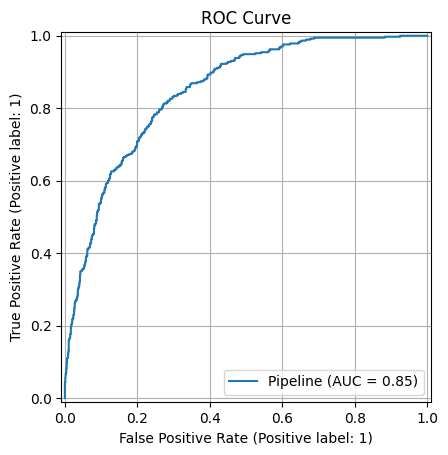

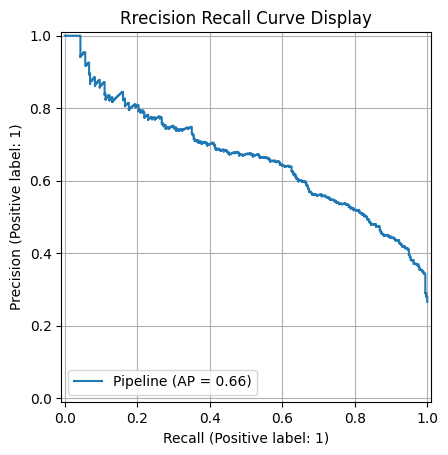

In [57]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve")
plt.grid(True)
plt.show()

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Rrecision Recall Curve Display")
plt.grid(True)
plt.show()

# Feature Importance

In [58]:
xgb_model=best_model.named_steps['model'].feature_importances_

feature_names=best_model.named_steps['preprocessor'].get_feature_names_out()

importance = pd.DataFrame({"Feature": feature_names,"importance": xgb_model})

importance.sort_values("importance",ascending=False).head(20)


,Feature,importance
26,nom__Contract_Two year,0.275193
25,nom__Contract_One year,0.204379
11,nom__InternetService_Fiber optic,0.109551
12,nom__InternetService_No,0.061613
28,nom__PaymentMethod_Electronic check,0.048163
0,num__tenure,0.037118
24,nom__StreamingMovies_Yes,0.031984
14,nom__OnlineSecurity_Yes,0.022550
6,bin__PaperlessBilling,0.022490
22,nom__StreamingTV_Yes,0.019800


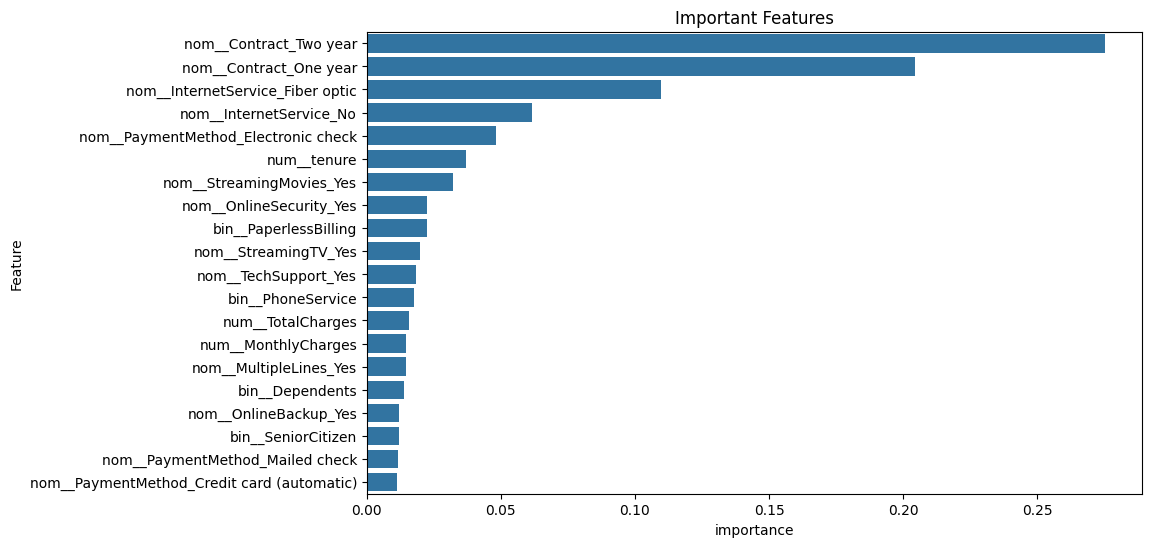

In [59]:
importance = importance.sort_values("importance",ascending=False).head(20)
plt.figure(figsize=(10,6))

sns.barplot(data=importance,x="importance",y="Feature")
plt.title("Important Features")
plt.show()

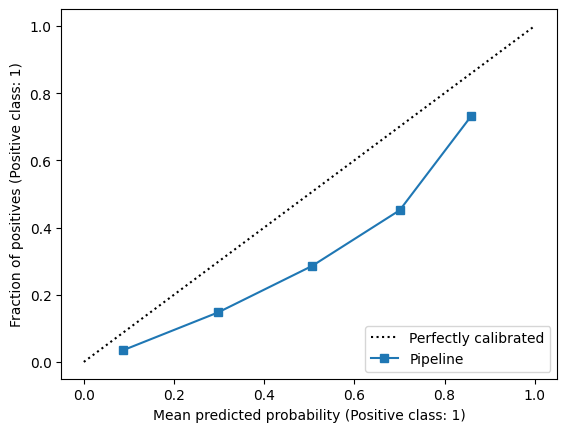

In [60]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.show()

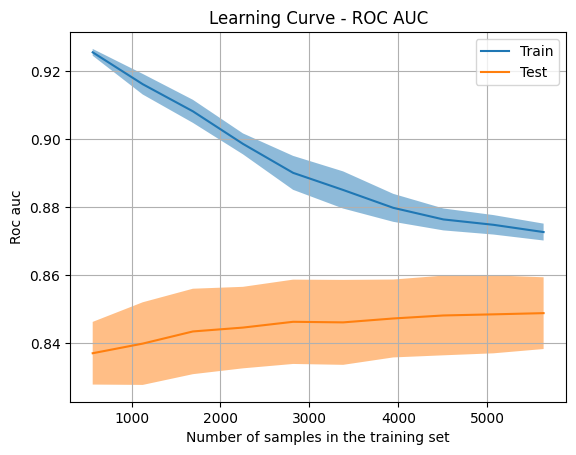

In [61]:
from sklearn.model_selection import LearningCurveDisplay
import matplotlib.pyplot as plt

LearningCurveDisplay.from_estimator(
    best_model,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.title("Learning Curve - ROC AUC")
plt.grid(True)
plt.show()

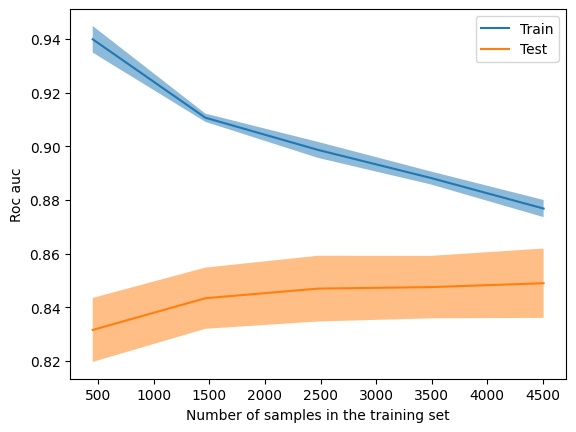

In [107]:
LearningCurveDisplay.from_estimator(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [62]:

import joblib
joblib.dump(best_model,'telecom_customer_churn_model_XGB.pkl')

['telecom_customer_churn_model_XGB.pkl']

In [109]:
# # LOAD THE MODEL
# model = joblib.load('telecom_customer_churn_model_XGB.pkl')
# predictions = model.predict()
# print(predictions)